# Chapter 2. Distribution Transport Before Flow Matching

This notebook is the paper-facing reproducibility notebook for Chapter 2. It expands the experiments cell by cell instead of delegating to a runner, so the data loading, cost construction, OT solution, path construction, energy computation, solver-in-loop proxy training, and artifact writing are all visible.

The chapter is intentionally limited to distribution transport before Flow Matching. Endpoint couplings are model-implied relations between snapshots, path constructions are illustrative bridges, the dynamic OT panel is a low-action energy proxy rather than a Benamou-Brenier solve, and the CNF section is a pedagogical solver-in-loop Neural ODE proxy rather than a full likelihood CNF benchmark.


## 1. Setup

This section fixes paths, random seed, plotting defaults, and the `quick_mode` setting used by the cloud reproducibility run. All figures are written to `figures/ch02`; all tables and the run summary are written to `outputs/ch02`.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig_ch02")
os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba_cache_ch02")

import json
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

started = time.perf_counter()
quick_mode = True
seed = 42
rng = np.random.default_rng(seed)

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents, PROJECT_ROOT / "flow_matching_for_dynamic_biology"]:
    if (candidate / "src").exists() and (candidate).exists():
        PROJECT_ROOT = candidate.resolve()
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_eb_timecourse_for_ch03
from src.metrics import coupling_l1_distance, mmd_rbf
from src.models import VelocityMLP
from src.ot import (
    compute_ot_coupling_from_cost,
    coupling_diagnostics,
    independent_coupling,
    pairwise_squared_distances,
    sample_pair_indices_from_coupling,
)
from src.paths import curved_path, linear_path
from src.toy import make_y_branching_snapshots
from src.utils import ensure_dir, save_table, savefig, set_seed

set_seed(seed)

paper_root = ensure_dir(PROJECT_ROOT)
fig_dir = ensure_dir(paper_root / "figures" / "ch02")
out_dir = ensure_dir(paper_root / "outputs" / "ch02")
eb_path = PROJECT_ROOT / "data" / "trajectorynet_eb" / "eb_velocity_v5.npz"

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"quick_mode={quick_mode}, seed={seed}")
print(f"fig_dir={fig_dir.relative_to(PROJECT_ROOT)}")
print(f"out_dir={out_dir.relative_to(PROJECT_ROOT)}")


PROJECT_ROOT=/import/home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology
quick_mode=True, seed=42
fig_dir=figures/ch02
out_dir=outputs/ch02


In [2]:
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from IPython.display import Image, display

mpl.rcParams.update(
    {
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "svg.fonttype": "none",
    }
)

source_time = "1"
target_time = "2"
n_source_ot = 250
n_target_ot = 250
max_cells_per_time = 900
cost_space = "PC-20"
visualization_space = "PHATE"
static_ot_main_epsilon = 0.05
sinkhorn_epsilons = [0.001, 0.01, 0.05, 0.1, 1.0, 5.0]

concept_boundaries = [
    "OT endpoint relation is model-implied, not observed lineage.",
    "Path energy is computed in PC-20.",
    "Dynamic OT panel is low-action intuition, not solved Benamou-Brenier.",
    "Solver-in-loop baseline is not full likelihood CNF.",
    "Chapter 2 stops at the CNF training bottleneck; Flow Matching training is deferred to Chapter 3.",
]
concept_boundaries


['OT endpoint relation is model-implied, not observed lineage.',
 'Path energy is computed in PC-20.',
 'Dynamic OT panel is low-action intuition, not solved Benamou-Brenier.',
 'Solver-in-loop baseline is not full likelihood CNF.',
 'Chapter 2 stops at the CNF training bottleneck; Flow Matching training is deferred to Chapter 3.']

In [3]:
def display_path(path: Path, base: Path = paper_root) -> str:
    path = Path(path)
    try:
        return str(path.relative_to(base))
    except ValueError:
        return str(path)


def save_fig_both(fig, stem: str) -> list[str]:
    written = []
    for suffix in [".png", ".svg"]:
        path = savefig(fig, fig_dir / f"{stem}{suffix}", dpi=300)
        written.append(display_path(path))
    plt.close(fig)
    return written


def show_saved_png(stem: str):
    display(Image(filename=str(fig_dir / f"{stem}.png")))


def save_ch02_table(table: pd.DataFrame, filename: str) -> str:
    path = save_table(table, out_dir / filename)
    return display_path(path)


def sorted_time_labels(labels: np.ndarray) -> list[str]:
    values = np.unique(labels.astype(str)).tolist()

    def key(value: str):
        try:
            return (0, float(value))
        except ValueError:
            return (1, value)

    return sorted(values, key=key)


def subsample_indices(indices: np.ndarray, max_n: int, rng: np.random.Generator) -> np.ndarray:
    indices = np.asarray(indices, dtype=int)
    if len(indices) <= int(max_n):
        return np.sort(indices)
    return np.sort(rng.choice(indices, size=int(max_n), replace=False))


def median_positive_scale(C: np.ndarray) -> float:
    positive = np.asarray(C, dtype=float)[np.asarray(C) > 0]
    return float(np.median(positive)) if positive.size else 1.0


def coupling_diagnostic_row(method: str, epsilon, pi: np.ndarray, C_raw: np.ndarray, C_norm: np.ndarray, info: dict | None, cost_scale: float) -> dict:
    raw = coupling_diagnostics(pi, C_raw)
    norm = coupling_diagnostics(pi, C_norm)
    info = info or {}
    return {
        "method": method,
        "epsilon": np.nan if epsilon is None else float(epsilon),
        "expected_cost_raw": raw["expected_cost"],
        "expected_cost_normalized": norm["expected_cost"],
        "entropy": norm["entropy"],
        "effective_support": norm["effective_support"],
        "row_l1_error": norm["row_l1_error"],
        "col_l1_error": norm["col_l1_error"],
        "sinkhorn_converged": bool(info.get("sinkhorn_converged", False)) if epsilon is not None else np.nan,
        "sinkhorn_n_iter": int(info.get("n_iter", 0)) if epsilon is not None else np.nan,
        "sinkhorn_backend": str(info.get("backend", "independent")) if epsilon is not None else "independent",
        "cost_scale": float(cost_scale),
    }


def draw_endpoint_cloud(ax, X0_plot: np.ndarray, X1_plot: np.ndarray) -> None:
    ax.scatter(X0_plot[:, 0], X0_plot[:, 1], s=9, c="#4267B2", alpha=0.35, linewidths=0, label="source")
    ax.scatter(X1_plot[:, 0], X1_plot[:, 1], s=9, c="#D55E00", alpha=0.35, linewidths=0, label="target")


def draw_arrows(ax, X0_plot: np.ndarray, X1_plot: np.ndarray, i0: np.ndarray, i1: np.ndarray, color: str, alpha: float = 0.35, linewidth: float = 0.8, mutation_scale: float = 7.0) -> None:
    for src_idx, tgt_idx in zip(i0, i1):
        start = X0_plot[int(src_idx)]
        end = X1_plot[int(tgt_idx)]
        ax.annotate(
            "",
            xy=(end[0], end[1]),
            xytext=(start[0], start[1]),
            arrowprops={
                "arrowstyle": "-|>",
                "color": color,
                "alpha": float(alpha),
                "lw": float(linewidth),
                "mutation_scale": float(mutation_scale),
                "shrinkA": 0.0,
                "shrinkB": 0.0,
            },
            zorder=3,
        )


def path_stats(traj: np.ndarray, tau_grid: np.ndarray, straight_midpoint: np.ndarray) -> dict:
    traj = np.asarray(traj, dtype=float)
    tau_grid = np.asarray(tau_grid, dtype=float)
    dt = np.diff(tau_grid)
    dx = np.diff(traj, axis=0)
    segment_lengths = np.linalg.norm(dx, axis=-1)
    velocities = dx / dt[:, None, None]
    midpoint = traj[int(np.argmin(np.abs(tau_grid - 0.5)))]
    endpoint_dist = np.linalg.norm(traj[-1] - traj[0], axis=1)
    return {
        "mean_endpoint_distance": float(endpoint_dist.mean()),
        "mean_path_length": float(segment_lengths.sum(axis=0).mean()),
        "energy_proxy": float(np.mean(np.sum(velocities**2, axis=-1))),
        "midpoint_deviation": float(np.linalg.norm(midpoint - straight_midpoint, axis=1).mean()),
    }


def brownian_bridge_trajectories(x0: np.ndarray, x1: np.ndarray, tau_grid: np.ndarray, sigma: float, seed: int) -> np.ndarray:
    local_rng = np.random.default_rng(seed)
    tau_grid = np.asarray(tau_grid, dtype=float)
    dt = np.diff(tau_grid)
    increments = local_rng.normal(scale=np.sqrt(dt)[:, None, None], size=(len(dt), len(x0), x0.shape[1]))
    brownian = np.concatenate([np.zeros((1, len(x0), x0.shape[1])), np.cumsum(increments, axis=0)], axis=0)
    bridge_noise = brownian - tau_grid[:, None, None] * brownian[-1][None, :, :]
    base = (1.0 - tau_grid[:, None, None]) * x0[None, :, :] + tau_grid[:, None, None] * x1[None, :, :]
    return base + float(sigma) * bridge_noise


def energy_and_length_pc(traj: np.ndarray, tau_grid: np.ndarray) -> tuple[float, float]:
    tau_grid = np.asarray(tau_grid, dtype=float)
    dx = np.diff(traj, axis=0)
    dt = np.diff(tau_grid)
    velocities = dx / dt[:, None, None]
    energy = float(np.mean(np.sum(velocities**2, axis=-1)))
    length = float(np.linalg.norm(dx, axis=-1).sum(axis=0).mean())
    return energy, length


## 2. Load EB Data And Representation Roles

This experiment uses `data/trajectorynet_eb/eb_velocity_v5.npz`. The cost space is PC-20 because OT costs and energy proxies should be computed in a Euclidean feature space. PHATE is visualization only; it is not used to define transport cost.


In [4]:
eb = load_eb_timecourse_for_ch03(
    path=eb_path,
    cost_embedding="pcs",
    plot_embedding="phate",
    n_cost_dims=20,
    max_cells_per_time=max_cells_per_time,
    seed=seed,
)

X_pc20 = np.asarray(eb["X_cost"], dtype=float)
X_phate = np.asarray(eb["X_plot"], dtype=float)
time_labels = eb["time"].astype(str)
timepoints = sorted_time_labels(time_labels)

print(f"Loaded EB cells after per-time cap: {X_pc20.shape[0]}")
print(f"Cost matrix source: {eb_path.relative_to(PROJECT_ROOT)}")
print(f"Timepoints: {timepoints}")
eb["full_counts_by_time"].head()


Loaded EB cells after per-time cap: 4500
Cost matrix source: data/trajectorynet_eb/eb_velocity_v5.npz
Timepoints: ['0', '1', '2', '3', '4']


,source,cost_embedding,plot_embedding,n_cost_dims,time,n_cells
0,/import/home4/xmabs/flow_matching_for_dynamic_...,pcs,phate,20,0,2381
1,/import/home4/xmabs/flow_matching_for_dynamic_...,pcs,phate,20,1,4163
2,/import/home4/xmabs/flow_matching_for_dynamic_...,pcs,phate,20,2,3278
3,/import/home4/xmabs/flow_matching_for_dynamic_...,pcs,phate,20,3,3665
4,/import/home4/xmabs/flow_matching_for_dynamic_...,pcs,phate,20,4,3332


In [5]:
representation_roles = pd.DataFrame(
    [
        {
            "object": "X_pc20",
            "source_key": "pcs",
            "role": "OT cost construction and PC-20 energy proxy",
            "used_for_cost": True,
            "used_for_visualization": False,
            "shape": str(tuple(X_pc20.shape)),
        },
        {
            "object": "X_phate",
            "source_key": "phate",
            "role": "2D plotting of EB snapshots and arrows",
            "used_for_cost": False,
            "used_for_visualization": True,
            "shape": str(tuple(X_phate.shape)),
        },
        {
            "object": "time_labels",
            "source_key": "sample_labels",
            "role": "empirical snapshot index",
            "used_for_cost": False,
            "used_for_visualization": True,
            "shape": str(tuple(time_labels.shape)),
        },
    ]
)
representation_roles


,object,source_key,role,used_for_cost,used_for_visualization,shape
0,X_pc20,pcs,OT cost construction and PC-20 energy proxy,True,False,"(4500, 20)"
1,X_phate,phate,2D plotting of EB snapshots and arrows,False,True,"(4500, 2)"
2,time_labels,sample_labels,empirical snapshot index,False,True,"(4500,)"


## 3. Static OT On EB Snapshots

Question: if we only observe two EB snapshot distributions at source time `1` and target time `2`, how different is an independent endpoint relation from a cost-aware OT endpoint relation?

We cap each timepoint at 900 cells during loading, then use 250 source cells and 250 target cells for OT. Costs are squared distances in PC-20. PHATE is used only to draw endpoint clouds and arrows.


In [6]:
idx0_all = np.flatnonzero(time_labels == source_time)
idx1_all = np.flatnonzero(time_labels == target_time)
if len(idx0_all) == 0 or len(idx1_all) == 0:
    raise ValueError(f"EB source/target times {source_time}->{target_time} were not found.")

idx0 = subsample_indices(idx0_all, n_source_ot, rng)
idx1 = subsample_indices(idx1_all, n_target_ot, rng)

X0_cost = X_pc20[idx0]
X1_cost = X_pc20[idx1]
X0_plot = X_phate[idx0]
X1_plot = X_phate[idx1]

pd.DataFrame(
    [
        {"time": source_time, "available_after_cap": len(idx0_all), "used_for_ot": len(idx0)},
        {"time": target_time, "available_after_cap": len(idx1_all), "used_for_ot": len(idx1)},
    ]
)


,time,available_after_cap,used_for_ot
0,1,900,250
1,2,900,250


In [7]:
C_raw = pairwise_squared_distances(X0_cost, X1_cost)
cost_scale = median_positive_scale(C_raw)
C_norm = C_raw / max(cost_scale, 1e-12)

pd.DataFrame(
    [
        {
            "cost_space": cost_space,
            "C_raw_shape": str(tuple(C_raw.shape)),
            "cost_scale": cost_scale,
            "C_raw_min": float(C_raw.min()),
            "C_raw_median": float(np.median(C_raw)),
            "C_raw_max": float(C_raw.max()),
        }
    ]
)


,cost_space,C_raw_shape,cost_scale,C_raw_min,C_raw_median,C_raw_max
0,PC-20,"(250, 250)",252.759349,16.413849,252.759349,1385.148398


In [8]:
pi_ind = independent_coupling(len(X0_cost), len(X1_cost))
plans = {}
sinkhorn_infos = {}
coupling_rows = [
    coupling_diagnostic_row("independent", None, pi_ind, C_raw, C_norm, None, cost_scale)
]

for epsilon in sinkhorn_epsilons:
    pi, info = compute_ot_coupling_from_cost(
        C_norm,
        epsilon=float(epsilon),
        return_info=True,
        num_iter_max=5000,
        stop_thr=1e-9,
    )
    plans[float(epsilon)] = pi
    sinkhorn_infos[float(epsilon)] = info
    coupling_rows.append(coupling_diagnostic_row("sinkhorn_ot", epsilon, pi, C_raw, C_norm, info, cost_scale))

pi_main = plans[static_ot_main_epsilon]
coupling_table = pd.DataFrame(coupling_rows)
coupling_table


,method,epsilon,expected_cost_raw,expected_cost_normalized,entropy,effective_support,row_l1_error,col_l1_error,sinkhorn_converged,sinkhorn_n_iter,sinkhorn_backend,cost_scale
0,independent,NaN,299.604267,1.185334,11.042922,62500.000000,6.505213e-16,1.951564e-15,NaN,NaN,independent,252.759349
1,sinkhorn_ot,0.001,182.493993,0.722007,6.466120,642.984328,1.198533e-04,1.092876e-16,False,5000.0,scaling_fallback,252.759349
2,sinkhorn_ot,0.010,147.956585,0.585365,6.349275,572.078003,1.309716e-16,6.034569e-06,False,4999.0,pot,252.759349
3,sinkhorn_ot,0.050,161.363085,0.638406,8.256609,3853.005684,1.249001e-16,1.401640e-09,True,190.0,pot,252.759349
4,sinkhorn_ot,0.100,182.410027,0.721675,9.415359,12275.478591,9.540979e-17,5.979862e-10,True,60.0,pot,252.759349
5,sinkhorn_ot,1.000,277.714295,1.098730,10.999203,59826.430303,1.040834e-16,3.807718e-16,True,10.0,pot,252.759349
6,sinkhorn_ot,5.000,295.370632,1.168584,11.041239,62394.880953,7.719519e-17,3.504141e-16,True,10.0,pot,252.759349


In [9]:
table02_01_path = save_ch02_table(coupling_table, "table02_01_coupling_diagnostics.csv")
table02_01_path


'outputs/ch02/table02_01_coupling_diagnostics.csv'

In [10]:
i0_ind = rng.integers(0, len(X0_plot), size=32)
i1_ind = rng.integers(0, len(X1_plot), size=32)
i0_ot, i1_ot = sample_pair_indices_from_coupling(pi_main, batch_size=42, seed=seed + 10)
sampled_endpoint_pairs = pd.DataFrame(
    {
        "source_local_index": i0_ot,
        "target_local_index": i1_ot,
        "source_global_index": idx0[i0_ot],
        "target_global_index": idx1[i1_ot],
        "coupling": "sinkhorn_epsilon_0.05",
    }
)
sampled_endpoint_pairs.head()


,source_local_index,target_local_index,source_global_index,target_global_index,coupling
0,153,249,1427,2697,sinkhorn_epsilon_0.05
1,143,119,1404,2268,sinkhorn_epsilon_0.05
2,129,231,1358,2628,sinkhorn_epsilon_0.05
3,1,160,917,2400,sinkhorn_epsilon_0.05
4,137,211,1385,2560,sinkhorn_epsilon_0.05


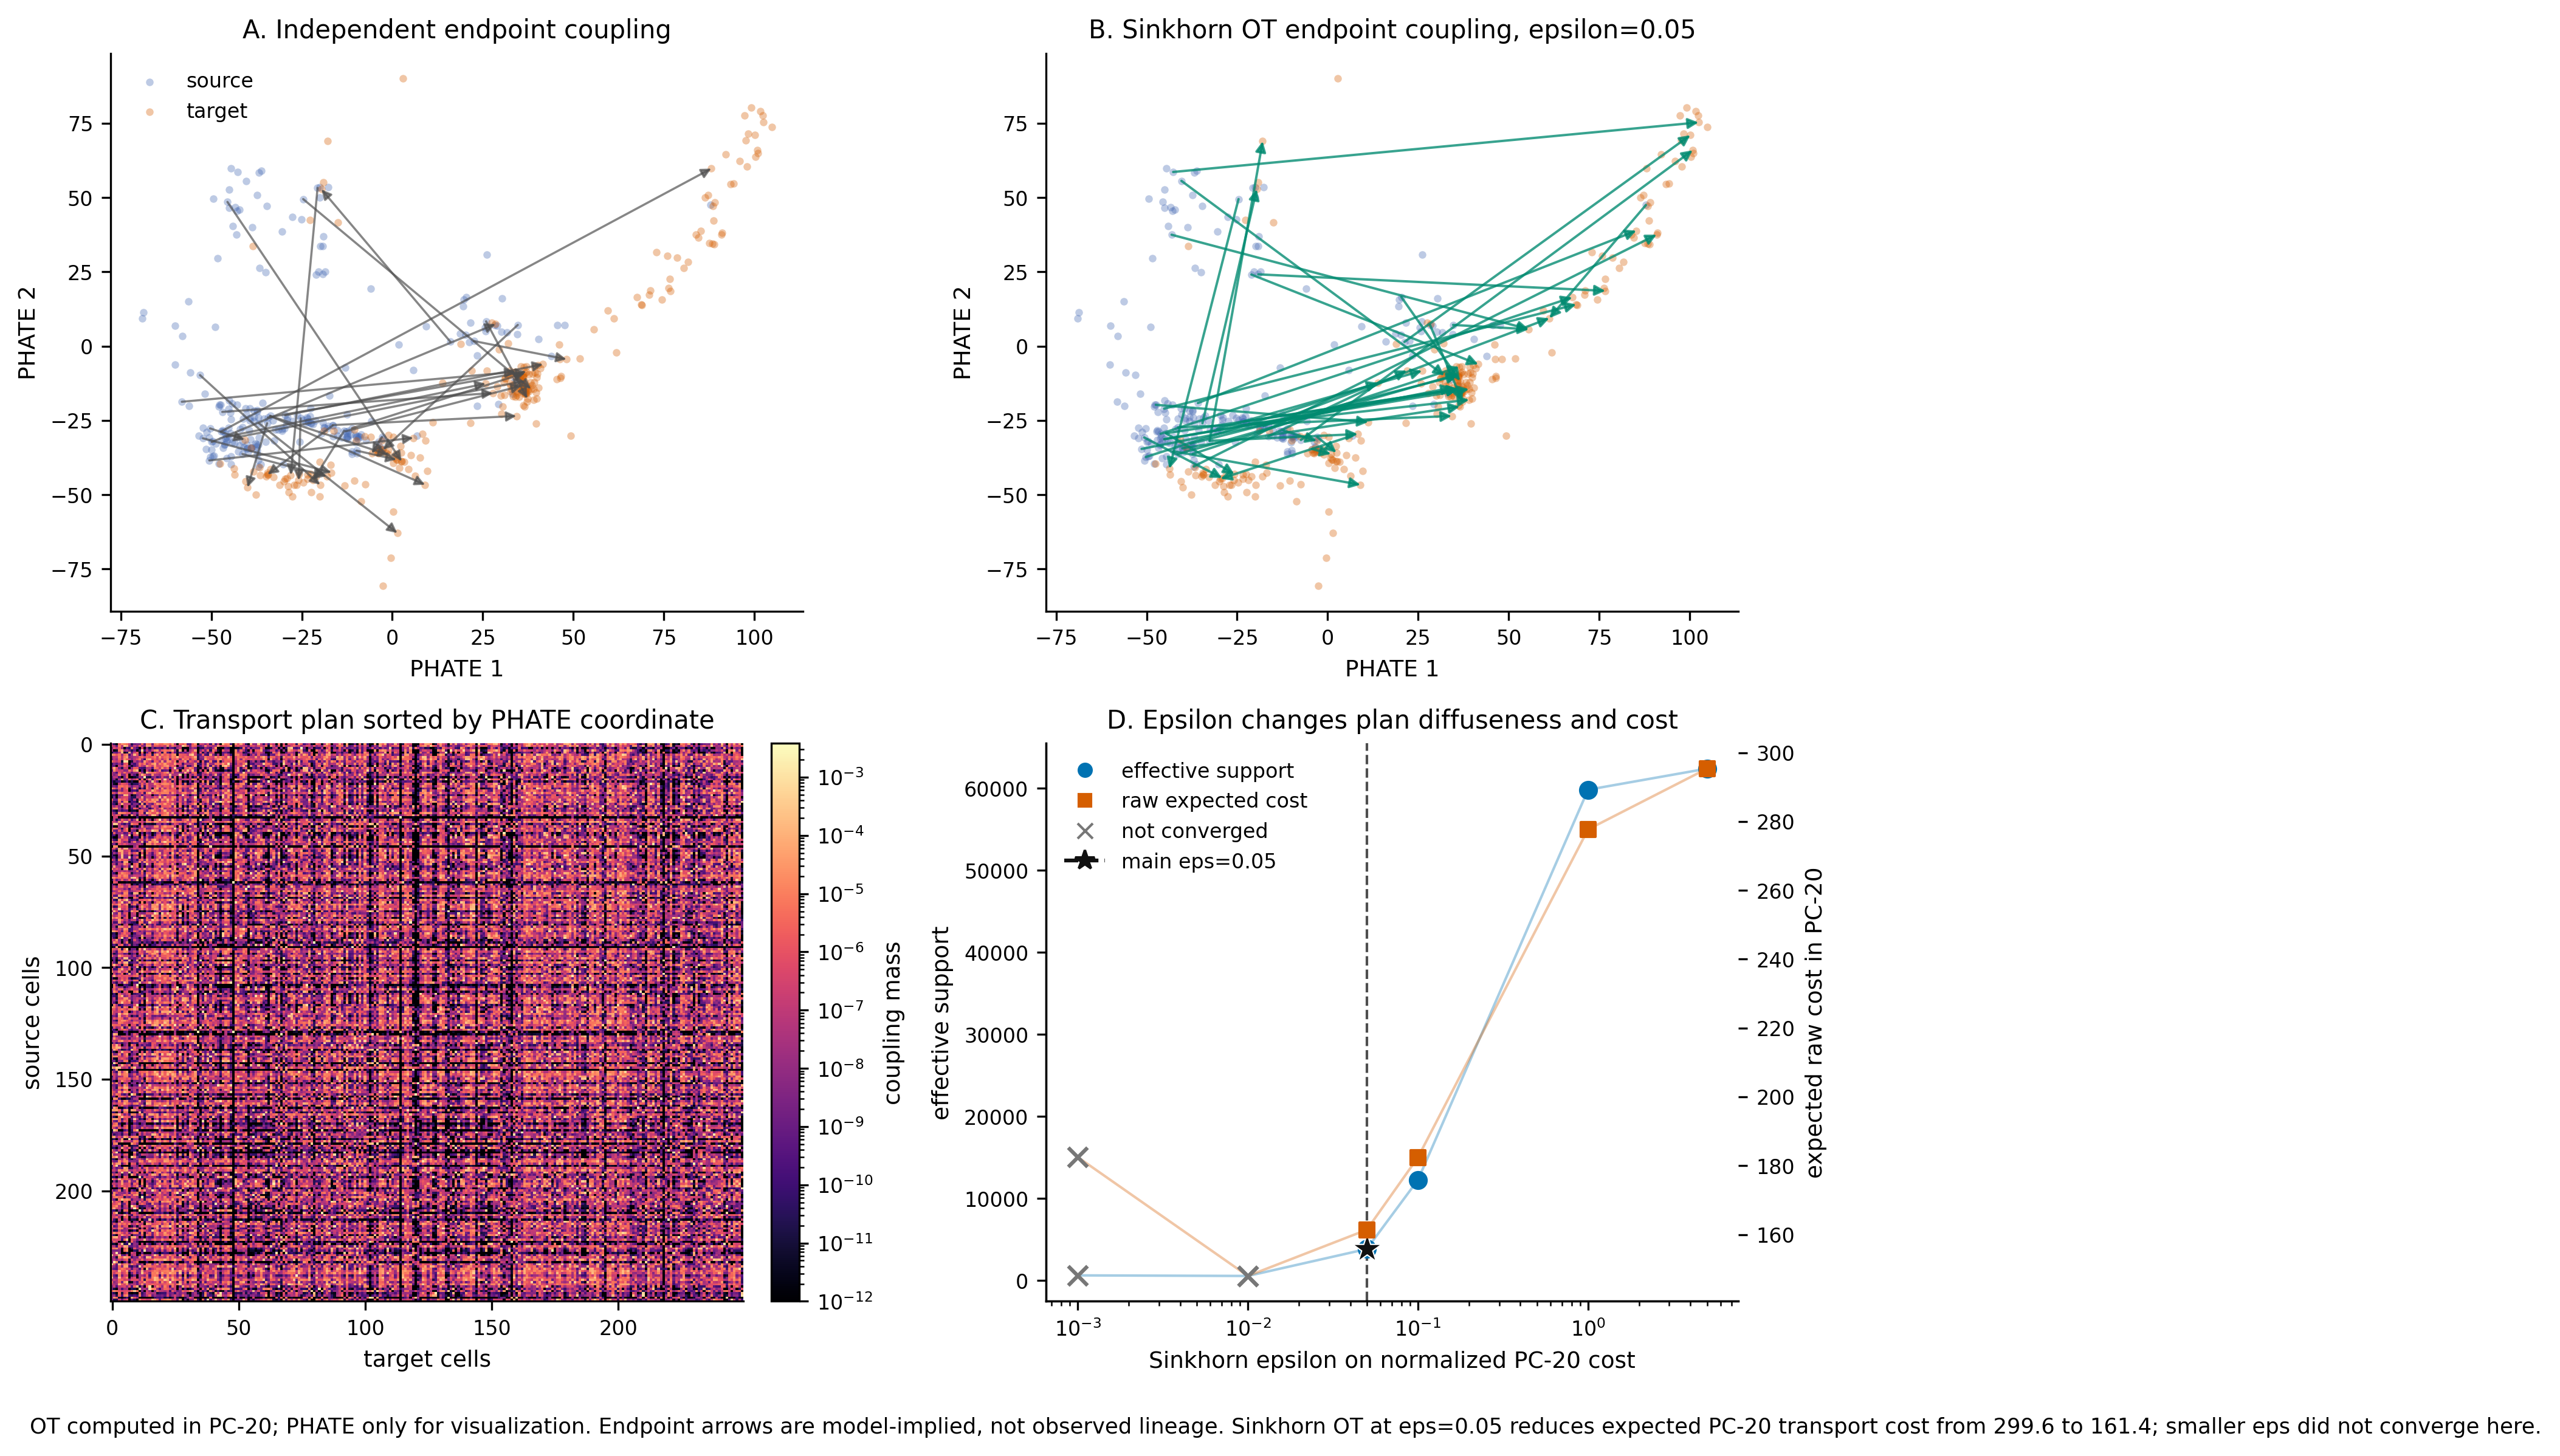

['figures/ch02/fig02_02_static_ot_endpoint_transport.png',
 'figures/ch02/fig02_02_static_ot_endpoint_transport.svg']

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10.2, 8.0))

ax = axes[0, 0]
draw_endpoint_cloud(ax, X0_plot, X1_plot)
draw_arrows(ax, X0_plot, X1_plot, i0_ind, i1_ind, color="#4D4D4D", alpha=0.68, linewidth=0.85, mutation_scale=8.0)
ax.set_title("A. Independent endpoint coupling")
ax.set_xlabel("PHATE 1")
ax.set_ylabel("PHATE 2")
ax.legend(frameon=False, loc="best")

ax = axes[0, 1]
draw_endpoint_cloud(ax, X0_plot, X1_plot)
draw_arrows(ax, X0_plot, X1_plot, i0_ot, i1_ot, color="#008A70", alpha=0.78, linewidth=0.95, mutation_scale=8.5)
ax.set_title(f"B. Sinkhorn OT endpoint coupling, epsilon={static_ot_main_epsilon}")
ax.set_xlabel("PHATE 1")
ax.set_ylabel("PHATE 2")

ax = axes[1, 0]
row_order = np.lexsort((X0_plot[:, 1], X0_plot[:, 0]))
col_order = np.lexsort((X1_plot[:, 1], X1_plot[:, 0]))
sorted_pi = pi_main[row_order][:, col_order]
positive = sorted_pi[sorted_pi > 0]
norm = LogNorm(vmin=max(float(positive.min()), 1e-12), vmax=float(sorted_pi.max())) if positive.size else None
im = ax.imshow(sorted_pi, aspect="auto", cmap="magma", norm=norm)
ax.set_title("C. Transport plan sorted by PHATE coordinate")
ax.set_xlabel("target cells")
ax.set_ylabel("source cells")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="coupling mass")

ax = axes[1, 1]
eps_df = coupling_table[coupling_table["method"] == "sinkhorn_ot"].copy()
converged = eps_df["sinkhorn_converged"].astype(bool).to_numpy()
eps_values = eps_df["epsilon"].to_numpy(dtype=float)
support_values = eps_df["effective_support"].to_numpy(dtype=float)
cost_values = eps_df["expected_cost_raw"].to_numpy(dtype=float)
ax.plot(eps_values, support_values, color="#0072B2", alpha=0.35, linewidth=1.0)
ax.scatter(eps_values[converged], support_values[converged], marker="o", s=42, color="#0072B2", zorder=4)
ax.scatter(eps_values[~converged], support_values[~converged], marker="x", s=58, color="#777777", linewidths=1.5, zorder=5)
ax.set_xscale("log")
ax.set_xlabel("Sinkhorn epsilon on normalized PC-20 cost")
ax.set_ylabel("effective support")
ax.axvline(static_ot_main_epsilon, color="#222222", linestyle="--", linewidth=1.0, alpha=0.8)
main_row = eps_df[np.isclose(eps_df["epsilon"], static_ot_main_epsilon)].iloc[0]
ax.scatter([static_ot_main_epsilon], [float(main_row["effective_support"])], marker="*", s=145, color="#111111", edgecolors="white", linewidths=0.5, zorder=6)

ax2 = ax.twinx()
ax2.plot(eps_values, cost_values, color="#D55E00", alpha=0.35, linewidth=1.0)
ax2.scatter(eps_values[converged], cost_values[converged], marker="s", s=34, color="#D55E00", zorder=4)
ax2.scatter(eps_values[~converged], cost_values[~converged], marker="x", s=58, color="#777777", linewidths=1.5, zorder=5)
ax2.set_ylabel("expected raw cost in PC-20")
ax.set_title("D. Epsilon changes plan diffuseness and cost")
ax.legend(
    handles=[
        Line2D([0], [0], marker="o", color="#0072B2", linestyle="None", markersize=5, label="effective support"),
        Line2D([0], [0], marker="s", color="#D55E00", linestyle="None", markersize=5, label="raw expected cost"),
        Line2D([0], [0], marker="x", color="#777777", linestyle="None", markersize=6, label="not converged"),
        Line2D([0], [0], marker="*", color="#111111", linestyle="--", markersize=8, label="main eps=0.05"),
    ],
    frameon=False,
    loc="best",
)

independent_expected_cost = float(coupling_table.loc[coupling_table["method"] == "independent", "expected_cost_raw"].iloc[0])
main_expected_cost = float(main_row["expected_cost_raw"])
fig.text(
    0.02,
    0.01,
    (
        "OT computed in PC-20; PHATE only for visualization. Endpoint arrows are model-implied, not observed lineage. "
        f"Sinkhorn OT at eps=0.05 reduces expected PC-20 transport cost from {independent_expected_cost:.1f} to {main_expected_cost:.1f}; smaller eps did not converge here."
    ),
    ha="left",
    va="bottom",
    fontsize=8.5,
)
fig.tight_layout(rect=[0, 0.035, 1, 1])
fig02_02_paths = save_fig_both(fig, "fig02_02_static_ot_endpoint_transport")
show_saved_png("fig02_02_static_ot_endpoint_transport")
fig02_02_paths


**Claim Boundary.** Sinkhorn OT at ε=0.05 reduces expected PC-20 transport cost from 299.6 to 161.4, while concentrating mass relative to the independent coupling. Smaller ε may reduce cost further but did not converge in this run. PHATE is visualization only. The OT plan is a model-implied endpoint coupling, not observed lineage.


## 4. Optional OT Cost Sensitivity Across PC Dimensions

Question: does the endpoint plan materially change if the same EB snapshots are compared in PC-5, PC-10, PC-20, or PC-50? We recompute Sinkhorn OT at ε=0.05 and compare each plan to the PC-20 plan by L1 distance.


In [12]:
eb50 = load_eb_timecourse_for_ch03(
    path=eb_path,
    cost_embedding="pcs",
    plot_embedding="phate",
    n_cost_dims=50,
    max_cells_per_time=max_cells_per_time,
    seed=seed,
)
labels50 = eb50["time"].astype(str)
rng_sensitivity = np.random.default_rng(seed + 90)
idx0_sens = subsample_indices(np.flatnonzero(labels50 == source_time), n_source_ot, rng_sensitivity)
idx1_sens = subsample_indices(np.flatnonzero(labels50 == target_time), n_target_ot, rng_sensitivity)

pc_dim_values = [5, 10, 20, 50]
sensitivity_plans = {}
sensitivity_rows = []
for pc_dims in pc_dim_values:
    X0_dim = np.asarray(eb50["X_cost"][idx0_sens, :pc_dims], dtype=float)
    X1_dim = np.asarray(eb50["X_cost"][idx1_sens, :pc_dims], dtype=float)
    C_dim_raw = pairwise_squared_distances(X0_dim, X1_dim)
    scale_dim = median_positive_scale(C_dim_raw)
    C_dim_norm = C_dim_raw / max(scale_dim, 1e-12)
    pi_dim, info_dim = compute_ot_coupling_from_cost(C_dim_norm, epsilon=static_ot_main_epsilon, return_info=True)
    sensitivity_plans[int(pc_dims)] = pi_dim
    diag_dim = coupling_diagnostics(pi_dim, C_dim_raw)
    sensitivity_rows.append(
        {
            "pc_dims": int(pc_dims),
            "epsilon": static_ot_main_epsilon,
            "expected_cost_raw": diag_dim["expected_cost"],
            "entropy": diag_dim["entropy"],
            "effective_support": diag_dim["effective_support"],
            "row_l1_error": diag_dim["row_l1_error"],
            "col_l1_error": diag_dim["col_l1_error"],
            "sinkhorn_converged": bool(info_dim.get("sinkhorn_converged", False)),
            "sinkhorn_backend": str(info_dim.get("backend", "")),
            "cost_scale": float(scale_dim),
        }
    )

pc20_plan_for_sensitivity = sensitivity_plans[20]
for row in sensitivity_rows:
    row["l1_to_pc20_plan"] = coupling_l1_distance(sensitivity_plans[int(row["pc_dims"])], pc20_plan_for_sensitivity)

ot_cost_sensitivity_table = pd.DataFrame(sensitivity_rows)
table02_optional_path = save_ch02_table(ot_cost_sensitivity_table, "table02_optional_ot_cost_sensitivity.csv")
ot_cost_sensitivity_table


,pc_dims,epsilon,expected_cost_raw,entropy,effective_support,row_l1_error,col_l1_error,sinkhorn_converged,sinkhorn_backend,cost_scale,l1_to_pc20_plan
0,5,0.05,67.782844,8.478102,4808.313063,9.714451e-17,7.961944e-09,True,pot,115.803392,1.302791
1,10,0.05,108.136977,8.283147,3956.627337,1.084202e-16,1.877906e-09,True,pot,181.769774,0.813855
2,20,0.05,157.675060,8.298430,4017.558193,1.786765e-16,1.174333e-08,True,pot,244.690180,0.000000
3,50,0.05,227.991956,8.517021,4999.141525,1.170938e-16,3.858475e-09,True,pot,316.379431,0.572888


**Claim Boundary.** The sensitivity table changes only the feature dimension used for the static endpoint cost. It does not establish a unique biological pairing, and it does not change the chapter's main PC-20 convention.


## 5. Same Endpoints, Different Paths

Question: does an endpoint coupling determine a trajectory? We use a toy 2D branching snapshot system, sample the same endpoint pairs from an OT endpoint coupling, and draw three bridge families: straight, curved deterministic, and Brownian stochastic.


In [13]:
toy = make_y_branching_snapshots(
    n_cells=400,
    timepoints=(0.0, 1.0),
    rare_fate_fraction=0.5,
    noise=0.075,
    seed=seed,
)
toy_X = np.asarray(toy.X, dtype=float)
toy_times = np.asarray(toy.time, dtype=float)
toy_X0 = toy_X[np.isclose(toy_times, 0.0)]
toy_X1 = toy_X[np.isclose(toy_times, 1.0)]

toy_C_raw = pairwise_squared_distances(toy_X0, toy_X1)
toy_C_norm = toy_C_raw / max(median_positive_scale(toy_C_raw), 1e-12)
toy_pi = compute_ot_coupling_from_cost(toy_C_norm, epsilon=static_ot_main_epsilon)
toy_i0, toy_i1 = sample_pair_indices_from_coupling(toy_pi, batch_size=80, seed=seed + 20)
toy_x0 = toy_X0[toy_i0]
toy_x1 = toy_X1[toy_i1]
toy_sampled_endpoint_pairs = pd.DataFrame({"source_local_index": toy_i0, "target_local_index": toy_i1})
toy_sampled_endpoint_pairs.head()


,source_local_index,target_local_index
0,121,173
1,149,106
2,156,26
3,57,113
4,138,129


In [14]:
tau_grid = np.linspace(0.0, 1.0, 51)
straight_bridge = np.stack([linear_path(toy_x0, toy_x1, tau)[0] for tau in tau_grid], axis=0)
curved_bridge = np.stack([curved_path(toy_x0, toy_x1, tau, curvature=0.20, direction="normal") for tau in tau_grid], axis=0)
brownian_bridge = brownian_bridge_trajectories(toy_x0, toy_x1, tau_grid, sigma=0.23, seed=seed + 21)
straight_midpoint = 0.5 * (toy_x0 + toy_x1)

{
    "straight_bridge_shape": straight_bridge.shape,
    "curved_bridge_shape": curved_bridge.shape,
    "brownian_bridge_shape": brownian_bridge.shape,
}


{'straight_bridge_shape': (51, 80, 2),
 'curved_bridge_shape': (51, 80, 2),
 'brownian_bridge_shape': (51, 80, 2)}

In [15]:
path_rows = []
for path_family, traj, notes in [
    ("straight bridge", straight_bridge, "Native 2D straight interpolation for the sampled endpoint pairs."),
    ("curved deterministic bridge", curved_bridge, "Native 2D deterministic bridge with fixed endpoint coupling."),
    ("Brownian stochastic bridge", brownian_bridge, "Discrete sampled-path proxy; not a strong action conclusion."),
]:
    stats = path_stats(traj, tau_grid, straight_midpoint)
    midpoint = traj[int(np.argmin(np.abs(tau_grid - 0.5)))]
    if path_family == "Brownian stochastic bridge":
        midpoint_spread = float(np.linalg.norm(midpoint - midpoint.mean(axis=0, keepdims=True), axis=1).mean())
    elif path_family == "straight bridge":
        midpoint_spread = 0.0
    else:
        midpoint_spread = float(np.std(np.linalg.norm(midpoint - straight_midpoint, axis=1)))
    path_rows.append(
        {
            "path_family": path_family,
            **stats,
            "midpoint_spread": midpoint_spread,
            "n_pairs": int(len(toy_x0)),
            "n_steps": int(len(tau_grid)),
            "notes": notes,
        }
    )

path_diagnostics = pd.DataFrame(path_rows)
table02_02_path = save_ch02_table(path_diagnostics, "table02_02_path_diagnostics.csv")
path_diagnostics


,path_family,mean_endpoint_distance,mean_path_length,energy_proxy,midpoint_deviation,midpoint_spread,n_pairs,n_steps,notes
0,straight bridge,2.484923,2.484923,6.185510,0.000000,0.000000,80,51,Native 2D straight interpolation for the sampl...
1,curved deterministic bridge,2.484923,2.714418,7.406079,0.496985,0.020657,80,51,Native 2D deterministic bridge with fixed endp...
2,Brownian stochastic bridge,2.484923,3.076432,11.316080,0.151573,0.470345,80,51,Discrete sampled-path proxy; not a strong acti...


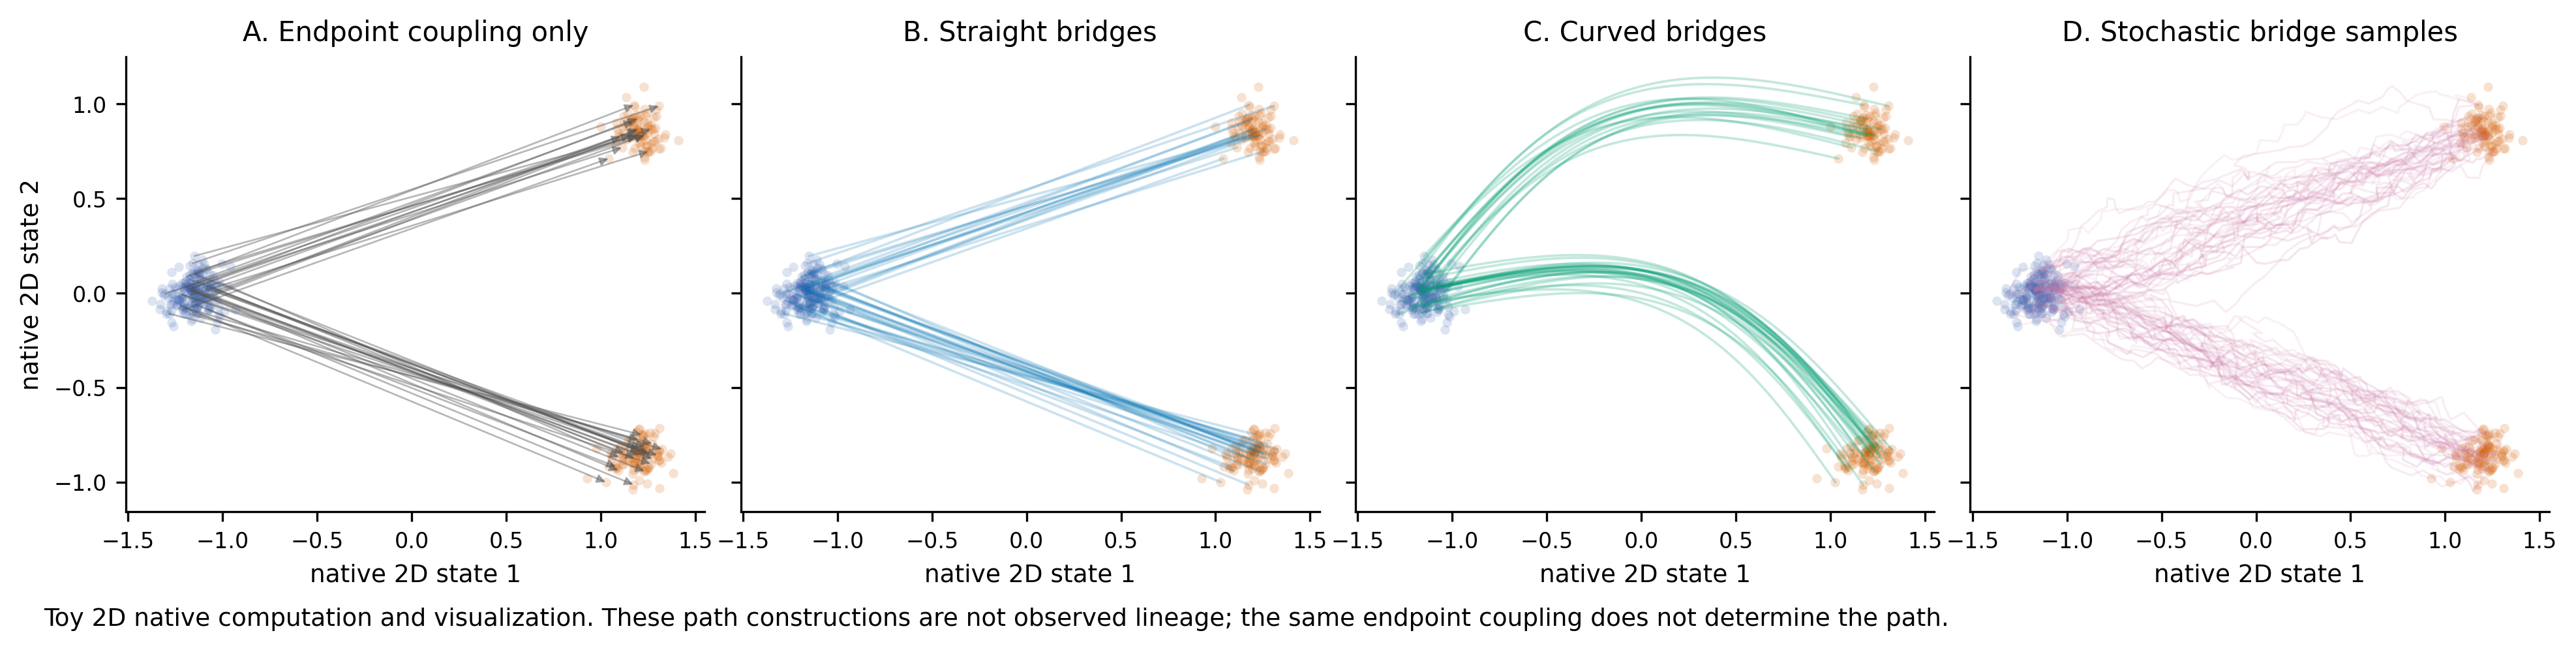

['figures/ch02/fig02_03_same_endpoints_different_paths.png',
 'figures/ch02/fig02_03_same_endpoints_different_paths.svg']

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(13.2, 3.4), sharex=True, sharey=True)
background_kw = dict(s=12, alpha=0.18, linewidths=0)
path_count = 42
for ax in axes:
    ax.scatter(toy_X0[:, 0], toy_X0[:, 1], c="#4267B2", **background_kw)
    ax.scatter(toy_X1[:, 0], toy_X1[:, 1], c="#D55E00", **background_kw)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("native 2D state 1")
axes[0].set_ylabel("native 2D state 2")

draw_arrows(axes[0], toy_X0, toy_X1, toy_i0[:38], toy_i1[:38], color="#555555", alpha=0.42, linewidth=0.65, mutation_scale=6.5)
axes[0].set_title("A. Endpoint coupling only")

for pair_idx in range(path_count):
    axes[1].plot(straight_bridge[:, pair_idx, 0], straight_bridge[:, pair_idx, 1], color="#0072B2", alpha=0.20, linewidth=0.9)
axes[1].set_title("B. Straight bridges")

for pair_idx in range(path_count):
    axes[2].plot(curved_bridge[:, pair_idx, 0], curved_bridge[:, pair_idx, 1], color="#009E73", alpha=0.23, linewidth=0.9)
axes[2].set_title("C. Curved bridges")

for repeat, alpha in enumerate([0.18, 0.13, 0.10]):
    stoch_plot = brownian_bridge_trajectories(toy_x0[:24], toy_x1[:24], tau_grid, sigma=0.23, seed=seed + 30 + repeat)
    for pair_idx in range(stoch_plot.shape[1]):
        axes[3].plot(stoch_plot[:, pair_idx, 0], stoch_plot[:, pair_idx, 1], color="#CC79A7", alpha=alpha, linewidth=0.8)
axes[3].set_title("D. Stochastic bridge samples")

fig.text(
    0.02,
    0.01,
    "Toy 2D native computation and visualization. These path constructions are not observed lineage; the same endpoint coupling does not determine the path.",
    ha="left",
    va="bottom",
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig02_03_paths = save_fig_both(fig, "fig02_03_same_endpoints_different_paths")
show_saved_png("fig02_03_same_endpoints_different_paths")
fig02_03_paths


**Claim Boundary.** These bridges share endpoint pairs but differ between endpoints. The example shows non-identifiability of paths from endpoint couplings; it is not a lineage reconstruction and it is not evidence that any one toy bridge is biologically observed.


## 6. Dynamic OT Low-Action Intuition On EB

Question: why does dynamic OT motivate low-action paths through the data geometry? We show EB empirical marginals, adjacent-time OT-like barycentric arrows, and a PC-20 straight path versus a perpendicular detour for the same sampled EB endpoint pairs.

This is explicitly an energy proxy, not a complete Benamou-Brenier dynamic OT solve.


In [17]:
try:
    import phate
except ImportError as exc:
    raise ImportError("phate is required for Chapter 2 EB visualization and out-of-sample path transforms.") from exc

phate_model = phate.PHATE(
    n_components=2,
    knn=5,
    decay=40,
    n_landmark=min(2000, int(X_pc20.shape[0])),
    random_state=int(seed),
    n_jobs=1,
    verbose=0,
)
phate_model.fit(X_pc20)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Pre-fit PHATE should not be used.*")
    X_phate_fit = np.asarray(phate_model.transform(X_pc20), dtype=float)

X_phate_fit.shape


  SGD-MDS may not have converged: stress changed by -1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.


(4500, 2)

In [18]:
rng_dynamic = np.random.default_rng(seed + 40)
adjacent_arrow_data = []
for edge_idx, (t0, t1) in enumerate(zip(timepoints[:-1], timepoints[1:])):
    edge_idx0_all = np.flatnonzero(time_labels == t0)
    edge_idx1_all = np.flatnonzero(time_labels == t1)
    edge_idx0 = subsample_indices(edge_idx0_all, 100, rng_dynamic)
    edge_idx1 = subsample_indices(edge_idx1_all, 100, rng_dynamic)
    edge_C_raw = pairwise_squared_distances(X_pc20[edge_idx0], X_pc20[edge_idx1])
    edge_C_norm = edge_C_raw / max(median_positive_scale(edge_C_raw), 1e-12)
    edge_pi = compute_ot_coupling_from_cost(edge_C_norm, epsilon=static_ot_main_epsilon)
    row_mass = np.clip(edge_pi.sum(axis=1, keepdims=True), 1e-12, None)
    n_edge_arrows = 8
    order = np.lexsort((X_phate_fit[edge_idx0, 1], X_phate_fit[edge_idx0, 0]))
    chosen_rows = order[np.linspace(0, len(order) - 1, n_edge_arrows, dtype=int)]
    starts = X_phate_fit[edge_idx0[chosen_rows]]
    barycentric_targets = (edge_pi[chosen_rows] @ X_phate_fit[edge_idx1]) / row_mass[chosen_rows]
    adjacent_arrow_data.append(
        {
            "starts": starts,
            "deltas": barycentric_targets - starts,
            "source_time": t0,
            "target_time": t1,
            "color": ["#0072B2", "#009E73", "#D55E00", "#CC79A7"][edge_idx % 4],
        }
    )

pd.DataFrame(
    {
        "edge": [f"{item['source_time']}->{item['target_time']}" for item in adjacent_arrow_data],
        "n_arrows": [len(item["starts"]) for item in adjacent_arrow_data],
    }
)


,edge,n_arrows
0,0->1,8
1,1->2,8
2,2->3,8
3,3->4,8


In [19]:
pair_i0, pair_i1 = sample_pair_indices_from_coupling(pi_main, batch_size=20, seed=seed + 60)
dynamic_pair_x0 = X0_cost[pair_i0]
dynamic_pair_x1 = X1_cost[pair_i1]
dynamic_tau_grid = np.linspace(0.0, 1.0, 41)

economical_pc20 = (
    (1.0 - dynamic_tau_grid[:, None, None]) * dynamic_pair_x0[None, :, :]
    + dynamic_tau_grid[:, None, None] * dynamic_pair_x1[None, :, :]
)

direction = dynamic_pair_x1 - dynamic_pair_x0
random_vec = rng_dynamic.normal(size=direction.shape)
projection = (
    np.sum(random_vec * direction, axis=1, keepdims=True)
    / np.clip(np.sum(direction**2, axis=1, keepdims=True), 1e-12, None)
) * direction
perpendicular = random_vec - projection
perpendicular /= np.clip(np.linalg.norm(perpendicular, axis=1, keepdims=True), 1e-12, None)
amplitude = 0.75 * np.linalg.norm(direction, axis=1, keepdims=True)
detour_pc20 = economical_pc20 + np.sin(np.pi * dynamic_tau_grid)[:, None, None] * amplitude[None, :, :] * perpendicular[None, :, :]

sampled_dynamic_endpoint_pairs = pd.DataFrame({"source_local_index": pair_i0, "target_local_index": pair_i1})
sampled_dynamic_endpoint_pairs.head()


,source_local_index,target_local_index
0,39,244
1,146,142
2,205,237
3,74,92
4,171,10


In [20]:
energy_economical, length_economical = energy_and_length_pc(economical_pc20, dynamic_tau_grid)
energy_detour, length_detour = energy_and_length_pc(detour_pc20, dynamic_tau_grid)
dynamic_ot_energy_ratio_detour_over_economical = energy_detour / max(energy_economical, 1e-12)

energy_table = pd.DataFrame(
    [
        {
            "path_family": "economical_straight_pc20",
            "energy_proxy": energy_economical,
            "mean_path_length_pc20": length_economical,
            "n_pairs": int(len(dynamic_pair_x0)),
            "n_steps": int(len(dynamic_tau_grid)),
            "notes": "Straight PC-20 bridge for sampled OT endpoint pairs.",
        },
        {
            "path_family": "detour_perpendicular_pc20",
            "energy_proxy": energy_detour,
            "mean_path_length_pc20": length_detour,
            "n_pairs": int(len(dynamic_pair_x0)),
            "n_steps": int(len(dynamic_tau_grid)),
            "notes": "Fixed random perpendicular perturbation in PC-20; energy proxy intuition only.",
        },
    ]
)
table02_03_path = save_ch02_table(energy_table, "table02_03_dynamic_ot_energy_proxy.csv")
energy_table


,path_family,energy_proxy,mean_path_length_pc20,n_pairs,n_steps,notes
0,economical_straight_pc20,204.625449,13.462652,20,41,Straight PC-20 bridge for sampled OT endpoint ...
1,detour_perpendicular_pc20,772.338220,25.121004,20,41,Fixed random perpendicular perturbation in PC-...


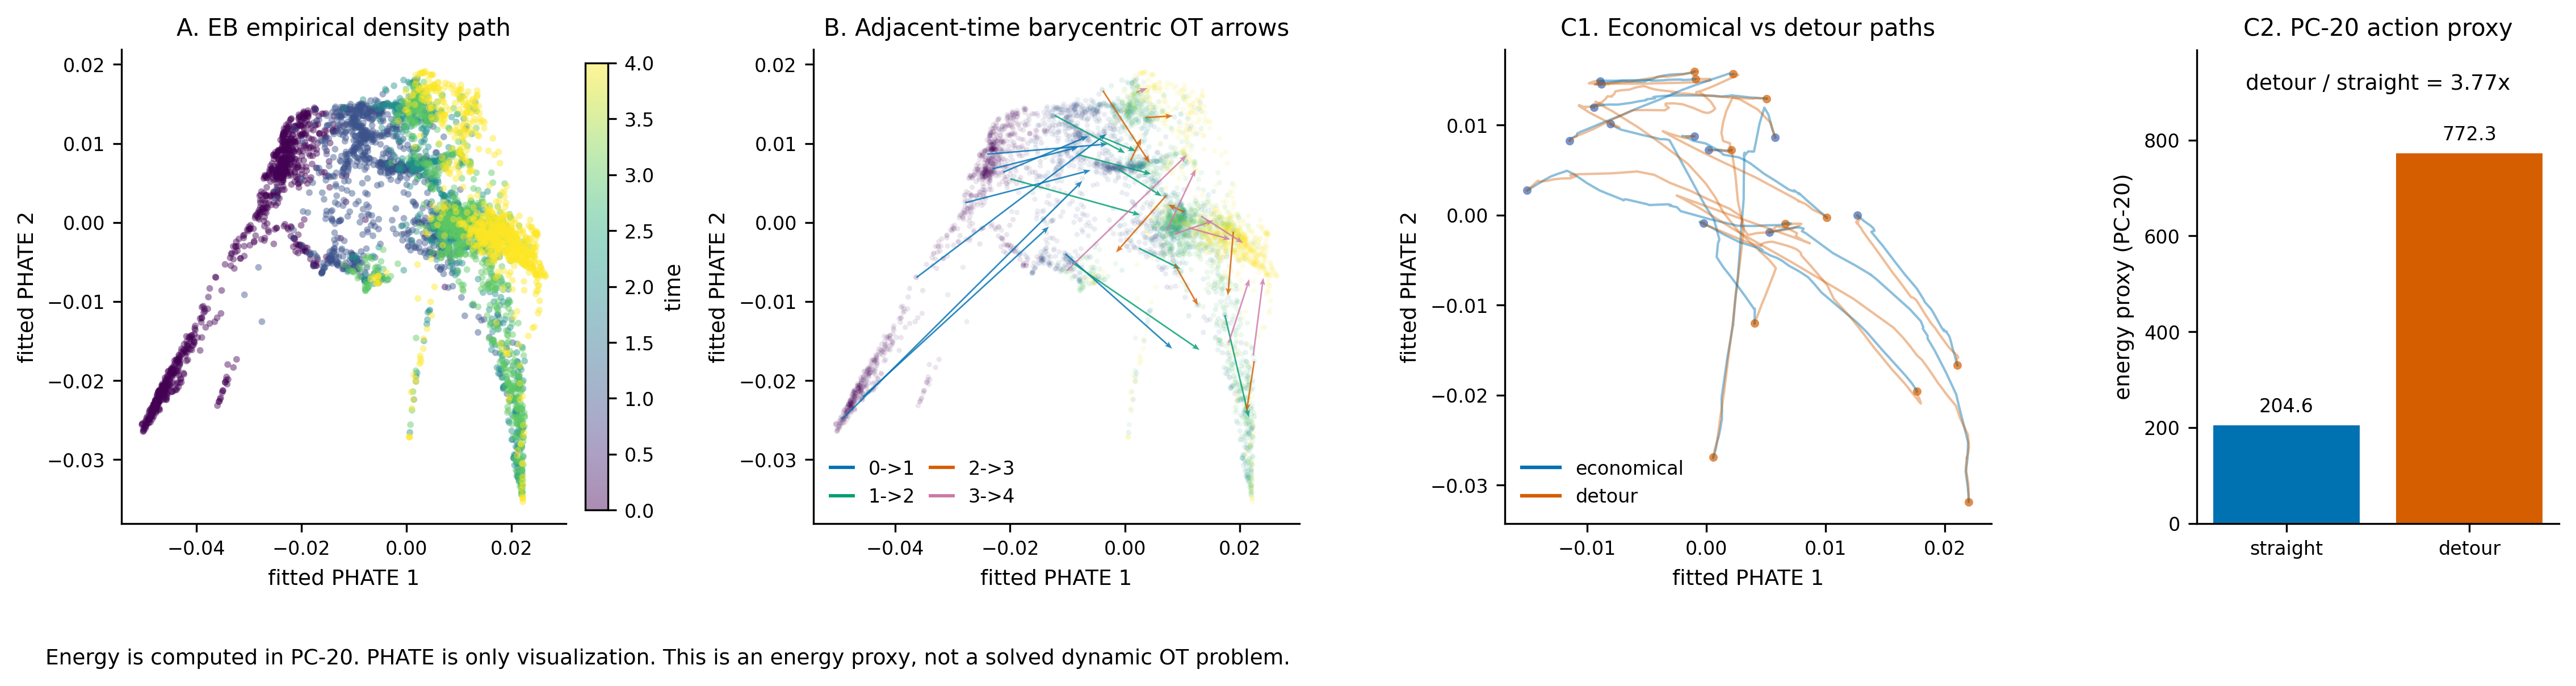

['figures/ch02/fig02_04_dynamic_ot_low_action.png',
 'figures/ch02/fig02_04_dynamic_ot_low_action.svg']

In [21]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Pre-fit PHATE should not be used.*")
    economical_phate = np.asarray(phate_model.transform(economical_pc20.reshape(-1, economical_pc20.shape[-1])), dtype=float).reshape(len(dynamic_tau_grid), len(dynamic_pair_x0), 2)
    detour_phate = np.asarray(phate_model.transform(detour_pc20.reshape(-1, detour_pc20.shape[-1])), dtype=float).reshape(len(dynamic_tau_grid), len(dynamic_pair_x0), 2)

fig, axes = plt.subplots(1, 4, figsize=(15.2, 4.0), gridspec_kw={"width_ratios": [1.1, 1.1, 1.1, 0.82]})
time_as_float = np.array([float(t) for t in time_labels], dtype=float)

sc = axes[0].scatter(X_phate_fit[:, 0], X_phate_fit[:, 1], c=time_as_float, s=8, alpha=0.45, cmap="viridis", linewidths=0)
axes[0].set_title("A. EB empirical density path")
axes[0].set_xlabel("fitted PHATE 1")
axes[0].set_ylabel("fitted PHATE 2")
fig.colorbar(sc, ax=axes[0], fraction=0.046, pad=0.04, label="time")

axes[1].scatter(X_phate_fit[:, 0], X_phate_fit[:, 1], c=time_as_float, s=5, alpha=0.10, cmap="viridis", linewidths=0)
for item in adjacent_arrow_data:
    starts = item["starts"]
    deltas = item["deltas"]
    axes[1].quiver(
        starts[:, 0],
        starts[:, 1],
        deltas[:, 0],
        deltas[:, 1],
        angles="xy",
        scale_units="xy",
        scale=1.0,
        color=item["color"],
        alpha=0.82,
        width=0.0032,
        headwidth=3.6,
        headlength=4.8,
        headaxislength=4.0,
        linewidths=0.25,
        zorder=4,
    )
    axes[1].plot([], [], color=item["color"], linewidth=1.4, label=f"{item['source_time']}->{item['target_time']}")
axes[1].set_title("B. Adjacent-time barycentric OT arrows")
axes[1].set_xlabel("fitted PHATE 1")
axes[1].set_ylabel("fitted PHATE 2")
axes[1].legend(frameon=False, loc="best", ncol=2, handlelength=1.2, columnspacing=0.8)

plot_pairs = min(12, economical_phate.shape[1])
for pair_idx in range(plot_pairs):
    axes[2].plot(economical_phate[:, pair_idx, 0], economical_phate[:, pair_idx, 1], color="#0072B2", alpha=0.45, linewidth=1.0)
    axes[2].plot(detour_phate[:, pair_idx, 0], detour_phate[:, pair_idx, 1], color="#D55E00", alpha=0.40, linewidth=1.0)
axes[2].scatter(economical_phate[0, :plot_pairs, 0], economical_phate[0, :plot_pairs, 1], s=13, c="#4267B2", alpha=0.7, linewidths=0)
axes[2].scatter(economical_phate[-1, :plot_pairs, 0], economical_phate[-1, :plot_pairs, 1], s=13, c="#D55E00", alpha=0.7, linewidths=0)
axes[2].set_title("C1. Economical vs detour paths")
axes[2].set_xlabel("fitted PHATE 1")
axes[2].set_ylabel("fitted PHATE 2")
axes[2].plot([], [], color="#0072B2", label="economical")
axes[2].plot([], [], color="#D55E00", label="detour")
axes[2].legend(frameon=False, loc="lower left")

energy_values = [energy_economical, energy_detour]
bars = axes[3].bar([0, 1], energy_values, color=["#0072B2", "#D55E00"])
axes[3].set_xticks([0, 1], ["straight", "detour"])
axes[3].set_ylabel("energy proxy (PC-20)")
axes[3].set_title("C2. PC-20 action proxy")
axes[3].set_ylim(0.0, max(energy_values) * 1.28)
axes[3].text(0.5, max(energy_values) * 1.16, f"detour / straight = {dynamic_ot_energy_ratio_detour_over_economical:.2f}x", ha="center", va="bottom", fontsize=9)
for bar, value in zip(bars, energy_values):
    axes[3].text(bar.get_x() + bar.get_width() / 2, value + max(energy_values) * 0.025, f"{value:.1f}", ha="center", va="bottom", fontsize=8)

fig.text(
    0.02,
    0.01,
    "Energy is computed in PC-20. PHATE is only visualization. This is an energy proxy, not a solved dynamic OT problem.",
    ha="left",
    va="bottom",
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.09, 1, 1])
fig02_04_paths = save_fig_both(fig, "fig02_04_dynamic_ot_low_action")
show_saved_png("fig02_04_dynamic_ot_low_action")
fig02_04_paths


**Claim Boundary.** The dynamic OT panel is low-action intuition, not solved Benamou-Brenier. The reported detour / straight value is a PC-20 energy proxy for constructed paths sharing sampled OT endpoints, not a proof that the empirical EB trajectory solves dynamic OT.


## 7. CNF Solver-In-Loop Training Bottleneck Proxy

Question: what is the training-control-flow bottleneck when a learned velocity field is evaluated by rolling an ODE inside each optimization step?

This is a pedagogical Neural ODE solver-in-the-loop proxy. It is not full likelihood CNF and does not compare against Flow Matching. In quick mode it uses `n_steps = 100`, `batch_size = 256`, and `n_solver_steps = 16`.


In [22]:
import torch

torch.set_num_threads(min(max(torch.get_num_threads(), 1), 4))
device = "cpu"
batch_size = 256
n_steps = 100 if quick_mode else 200
n_solver_steps = 16 if quick_mode else 24
eval_solver_steps = 32

def sample_gaussian_mixture_torch(n: int, centers: torch.Tensor, scale: float, generator, device: str):
    idx = torch.randint(0, centers.shape[0], (int(n),), generator=generator, device=device)
    return centers[idx] + float(scale) * torch.randn((int(n), centers.shape[1]), generator=generator, device=device)


def torch_mmd_rbf(X, Y, gamma: float = 0.5):
    dxx = torch.cdist(X, X).pow(2)
    dyy = torch.cdist(Y, Y).pow(2)
    dxy = torch.cdist(X, Y).pow(2)
    return torch.exp(-gamma * dxx).mean() + torch.exp(-gamma * dyy).mean() - 2.0 * torch.exp(-gamma * dxy).mean()


def euler_integrate_torch(model, x0, n_solver_steps: int):
    x = x0
    dt = 1.0 / int(n_solver_steps)
    for step in range(int(n_solver_steps)):
        t = torch.full((x.shape[0], 1), step * dt, dtype=x.dtype, device=x.device)
        x = x + dt * model(x, t)
    return x, int(n_solver_steps)

{"n_steps": n_steps, "batch_size": batch_size, "n_solver_steps": n_solver_steps}


{'n_steps': 100, 'batch_size': 256, 'n_solver_steps': 16}

In [23]:
set_seed(seed)
angles = torch.linspace(0, 2 * np.pi, 9, dtype=torch.float32)[:-1]
source_centers = torch.stack([1.2 * torch.cos(angles), 1.2 * torch.sin(angles)], dim=1).to(device)
rot = torch.tensor([[0.78, -0.62], [0.62, 0.78]], dtype=torch.float32, device=device)
target_centers = (source_centers @ rot.T) * torch.tensor([0.9, 1.15], device=device) + torch.tensor([0.65, -0.25], device=device)
torch_generator = torch.Generator(device=device)
torch_generator.manual_seed(seed)

def sample_source(n: int):
    return sample_gaussian_mixture_torch(n, source_centers, 0.16, torch_generator, device)


def sample_target(n: int):
    return sample_gaussian_mixture_torch(n, target_centers, 0.18, torch_generator, device)


cnf_proxy_model = VelocityMLP(x_dim=2, hidden_dim=64, hidden_layers=2).to(device)
cnf_proxy_optimizer = torch.optim.Adam(cnf_proxy_model.parameters(), lr=1e-3)


In [24]:
cnf_step_times = []
cnf_nfe_values = []
cnf_loss_trace = []
cnf_training_start = time.perf_counter()
final_loss = np.nan

for step in range(n_steps):
    x0_batch = sample_source(batch_size)
    target_batch = sample_target(batch_size)
    cnf_proxy_optimizer.zero_grad(set_to_none=True)
    step_start = time.perf_counter()
    pred_batch, nfe = euler_integrate_torch(cnf_proxy_model, x0_batch, n_solver_steps=n_solver_steps)
    loss = torch_mmd_rbf(pred_batch, target_batch, gamma=0.6)
    loss.backward()
    cnf_proxy_optimizer.step()
    elapsed = time.perf_counter() - step_start
    cnf_step_times.append(elapsed)
    cnf_nfe_values.append(nfe)
    final_loss = float(loss.detach().cpu())
    cnf_loss_trace.append(final_loss)

cnf_total_wall_time = time.perf_counter() - cnf_training_start
cnf_step_times = np.asarray(cnf_step_times)
cnf_nfe_values = np.asarray(cnf_nfe_values)
{"total_wall_time_sec": cnf_total_wall_time, "final_loss": final_loss}


{'total_wall_time_sec': 1.6559573486447334, 'final_loss': 0.011843204498291016}

In [25]:
with torch.no_grad():
    eval_source = sample_source(512)
    eval_target = sample_target(512)
    eval_pred, _ = euler_integrate_torch(cnf_proxy_model, eval_source.clone(), n_solver_steps=eval_solver_steps)

final_distribution_mmd = mmd_rbf(eval_pred.cpu().numpy(), eval_target.cpu().numpy())
cnf_training_table = pd.DataFrame(
    [
        {
            "method": "solver-in-the-loop Neural ODE training proxy",
            "n_steps": int(n_steps),
            "batch_size": int(batch_size),
            "mean_time_per_step_ms": float(cnf_step_times.mean() * 1000.0),
            "median_time_per_step_ms": float(np.median(cnf_step_times) * 1000.0),
            "nfe_per_step_mean": float(cnf_nfe_values.mean()),
            "nfe_per_step_median": float(np.median(cnf_nfe_values)),
            "total_wall_time_sec": float(cnf_total_wall_time),
            "final_loss": float(final_loss),
            "final_distribution_mmd": float(final_distribution_mmd),
            "notes": "Pedagogical proxy: backpropagates through a differentiable Euler ODE rollout with MMD loss; no likelihood or divergence tracking.",
        }
    ]
)
table02_04_path = save_ch02_table(cnf_training_table, "table02_04_cnf_training_bottleneck.csv")
table02_04_proxy_path = save_ch02_table(cnf_training_table, "table02_04_training_cost_proxy.csv")
cnf_training_table


,method,n_steps,batch_size,mean_time_per_step_ms,median_time_per_step_ms,nfe_per_step_mean,nfe_per_step_median,total_wall_time_sec,final_loss,final_distribution_mmd,notes
0,solver-in-the-loop Neural ODE training proxy,100,256,16.384809,16.219877,16.0,16.0,1.655957,0.011843,0.000787,Pedagogical proxy: backpropagates through a di...


In [26]:
label = ["solver-in-loop\nproxy"]
mean_step_ms = float(cnf_training_table.iloc[0]["mean_time_per_step_ms"])
median_step_ms = float(cnf_training_table.iloc[0]["median_time_per_step_ms"])
total_wall_sec = float(cnf_training_table.iloc[0]["total_wall_time_sec"])
nfe_per_step = float(cnf_training_table.iloc[0]["nfe_per_step_mean"])
final_mmd_value = float(cnf_training_table.iloc[0]["final_distribution_mmd"])

cnf_training_bottleneck_scalars = {
    "mean_time_per_step_ms": mean_step_ms,
    "median_time_per_step_ms": median_step_ms,
    "total_wall_time_sec": total_wall_sec,
    "nfe_per_step_mean": nfe_per_step,
    "final_distribution_mmd": final_mmd_value,
}
cnf_training_bottleneck_scalars


{'mean_time_per_step_ms': 16.38480894267559,
 'median_time_per_step_ms': 16.21987670660019,
 'total_wall_time_sec': 1.6559573486447334,
 'nfe_per_step_mean': 16.0,
 'final_distribution_mmd': 0.0007868466578970779}

**Claim Boundary.** Solver-in-loop baseline is not full likelihood CNF. The table reports a pedagogical differentiable Euler rollout with an MMD endpoint loss. Chapter 2 stops at the CNF training bottleneck; Flow Matching training is deferred to Chapter 3.


## 8. Run Summary And Artifact Check

The final cell records the reproducibility settings, key scalar outputs, written artifacts, and concept boundaries in `outputs/ch02/ch02_run_summary.json`.


In [27]:
figures_written = fig02_02_paths + fig02_03_paths + fig02_04_paths
tables_written = [
    table02_01_path,
    table02_optional_path,
    table02_02_path,
    table02_03_path,
    table02_04_path,
    table02_04_proxy_path,
]

summary = {
    "quick_mode": bool(quick_mode),
    "seed": int(seed),
    "runtime_sec": float(time.perf_counter() - started),
    "eb_path": str(eb_path.relative_to(PROJECT_ROOT)),
    "source_time": source_time,
    "target_time": target_time,
    "n_source_ot": int(len(X0_cost)),
    "n_target_ot": int(len(X1_cost)),
    "cost_space": cost_space,
    "visualization_space": visualization_space,
    "static_ot_main_epsilon": float(static_ot_main_epsilon),
    "dynamic_ot_energy_ratio_detour_over_economical": float(dynamic_ot_energy_ratio_detour_over_economical),
    "cnf_proxy_mean_step_time_ms": float(mean_step_ms),
    "cnf_proxy_nfe_per_step": float(nfe_per_step),
    "figures_written": figures_written,
    "tables_written": tables_written,
    "concept_boundaries": concept_boundaries,
}

summary_path = out_dir / "ch02_run_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, sort_keys=True) + "\n")
summary


{'quick_mode': True,
 'seed': 42,
 'runtime_sec': 37.153613675385714,
 'eb_path': 'data/trajectorynet_eb/eb_velocity_v5.npz',
 'source_time': '1',
 'target_time': '2',
 'n_source_ot': 250,
 'n_target_ot': 250,
 'cost_space': 'PC-20',
 'visualization_space': 'PHATE',
 'static_ot_main_epsilon': 0.05,
 'dynamic_ot_energy_ratio_detour_over_economical': 3.7743996401848214,
 'cnf_proxy_mean_step_time_ms': 16.38480894267559,
 'cnf_proxy_nfe_per_step': 16.0,
 'figures_written': ['figures/ch02/fig02_02_static_ot_endpoint_transport.png',
  'figures/ch02/fig02_02_static_ot_endpoint_transport.svg',
  'figures/ch02/fig02_03_same_endpoints_different_paths.png',
  'figures/ch02/fig02_03_same_endpoints_different_paths.svg',
  'figures/ch02/fig02_04_dynamic_ot_low_action.png',
  'figures/ch02/fig02_04_dynamic_ot_low_action.svg'],
 'tables_written': ['outputs/ch02/table02_01_coupling_diagnostics.csv',
  'outputs/ch02/table02_optional_ot_cost_sensitivity.csv',
  'outputs/ch02/table02_02_path_diagnostics.

In [28]:
expected_artifact_paths = [
    fig_dir / "fig02_02_static_ot_endpoint_transport.png",
    fig_dir / "fig02_02_static_ot_endpoint_transport.svg",
    fig_dir / "fig02_03_same_endpoints_different_paths.png",
    fig_dir / "fig02_03_same_endpoints_different_paths.svg",
    fig_dir / "fig02_04_dynamic_ot_low_action.png",
    fig_dir / "fig02_04_dynamic_ot_low_action.svg",
    out_dir / "table02_01_coupling_diagnostics.csv",
    out_dir / "table02_optional_ot_cost_sensitivity.csv",
    out_dir / "table02_02_path_diagnostics.csv",
    out_dir / "table02_03_dynamic_ot_energy_proxy.csv",
    out_dir / "table02_04_cnf_training_bottleneck.csv",
    out_dir / "table02_04_training_cost_proxy.csv",
    out_dir / "ch02_run_summary.json",
]
missing_artifacts = [str(path.relative_to(PROJECT_ROOT)) for path in expected_artifact_paths if not path.exists()]
assert not missing_artifacts, missing_artifacts

key_numbers = {
    "independent_expected_cost": independent_expected_cost,
    "sinkhorn_eps_0_05_expected_cost": main_expected_cost,
    "detour_over_straight_energy_ratio": dynamic_ot_energy_ratio_detour_over_economical,
    "cnf_proxy_nfe_per_step": nfe_per_step,
}
key_numbers


{'independent_expected_cost': 299.6042673818734,
 'sinkhorn_eps_0_05_expected_cost': 161.36308528833905,
 'detour_over_straight_energy_ratio': 3.7743996401848214,
 'cnf_proxy_nfe_per_step': 16.0}

**Final Chapter Boundary.** The next chapter asks whether the same velocity field can be trained without solving the learned ODE inside the training loop. This notebook does not introduce a Flow Matching training experiment.
